# LAB 04 - Principle Component Analysis (PCA)

* Created By : RAKSHITHA V S 2348448 <BR>
* 3 MDS B

* The main goal of Principal Component Analysis (PCA) is to reduce the dimensionality of a dataset while preserving the most important patterns or relationships between the variables without any prior knowledge of the target variables.
* Principal Component Analysis (PCA) is a statistical procedure that uses an orthogonal transformation that converts a set of correlated variables to a set of uncorrelated variables.PCA is the most widely used tool in exploratory data analysis and in machine learning for predictive models.
* Principal Component Analysis (PCA) is an unsupervised learning algorithm technique used to examine the interrelations among a set of variables. It is also known as a general factor analysis where regression determines a line of best fit.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/TRISEM 3-ML/energy_efficiency_data.csv")
df = df.drop_duplicates()
df

,Relative_Compactness,Surface_Area,Roof_Area,Overall_Height,Heating_Load,Cooling_Load
0,0.98,514.5,110.25,7.0,15.55,21.33
4,0.90,563.5,122.50,7.0,20.84,28.28
5,0.90,563.5,122.50,7.0,21.46,25.38
6,0.90,563.5,122.50,7.0,20.71,25.16
7,0.90,563.5,122.50,7.0,19.68,29.60
...,...,...,...,...,...,...
763,0.64,784.0,220.50,3.5,17.88,21.40
764,0.62,808.5,220.50,3.5,16.54,16.88
765,0.62,808.5,220.50,3.5,16.44,17.11
766,0.62,808.5,220.50,3.5,16.48,16.61


### Information about the dataset

The dataset contains information about building characteristics

* <b>Relative_Compactness:</b> represents the compactness of the building relative to its shape. It could be calculated as the ratio of the volume of the building to the surface area.

* <b>Surface Area: </b> This represents the total surface area of the building.

* <b>Roof Area: </b>It represents the total area of the building's roof.

* <b>Overall_Height: </b>This feature indicates the overall height of the building.

* <b>Heating_Load: </b>represents the heating load of the building, which is the amount of energy required to maintain the desired temperature indoors.

* <b>Cooling_Load: </b>this feature represents the cooling load of the building, which is the amount of energy required to maintain the desired temperature indoors during cooling.

### Basic EDA to explore the dataset

In [ ]:
df.head()

,Relative_Compactness,Surface_Area,Roof_Area,Overall_Height,Heating_Load,Cooling_Load
0,0.98,514.5,110.25,7.0,15.55,21.33
4,0.90,563.5,122.50,7.0,20.84,28.28
5,0.90,563.5,122.50,7.0,21.46,25.38
6,0.90,563.5,122.50,7.0,20.71,25.16
7,0.90,563.5,122.50,7.0,19.68,29.60


In [ ]:
df.tail()

,Relative_Compactness,Surface_Area,Roof_Area,Overall_Height,Heating_Load,Cooling_Load
763,0.64,784.0,220.5,3.5,17.88,21.40
764,0.62,808.5,220.5,3.5,16.54,16.88
765,0.62,808.5,220.5,3.5,16.44,17.11
766,0.62,808.5,220.5,3.5,16.48,16.61
767,0.62,808.5,220.5,3.5,16.64,16.03


In [ ]:
df.shape

(756, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 756 entries, 0 to 767
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Relative_Compactness  756 non-null    float64
 1   Surface_Area          756 non-null    float64
 2   Roof_Area             756 non-null    float64
 3   Overall_Height        756 non-null    float64
 4   Heating_Load          756 non-null    float64
 5   Cooling_Load          756 non-null    float64
dtypes: float64(6)
memory usage: 41.3 KB


In [ ]:
df.describe()

,Relative_Compactness,Surface_Area,Roof_Area,Overall_Height,Heating_Load,Cooling_Load
count,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000
mean,0.763849,671.870370,176.620370,5.254630,22.403413,24.658399
std,0.105058,87.701698,45.025744,1.751152,10.122139,9.551984
min,0.620000,514.500000,110.250000,3.500000,6.010000,10.900000
25%,0.690000,612.500000,147.000000,3.500000,12.970000,15.590000
50%,0.760000,661.500000,147.000000,7.000000,19.165000,22.625000
75%,0.820000,735.000000,220.500000,7.000000,31.852500,33.185000
max,0.980000,808.500000,220.500000,7.000000,43.100000,48.030000


### Standardizing the dataset

In [ ]:
df_origin = df
for col in df.columns:
    df[col] = (df[col] - df[col].mean()) / df[col].std()
df_st_backup = df
df.head()

,Relative_Compactness,Surface_Area,Roof_Area,Overall_Height,Heating_Load,Cooling_Load
0,2.057439,-1.794382,-1.474054,0.996698,-0.677072,-0.348451
4,1.295956,-1.235670,-1.201987,0.996698,-0.154455,0.379146
5,1.295956,-1.235670,-1.201987,0.996698,-0.093203,0.075545
6,1.295956,-1.235670,-1.201987,0.996698,-0.167298,0.052513
7,1.295956,-1.235670,-1.201987,0.996698,-0.269055,0.517338


### Checking for any independent variables

In [ ]:
R = df.corr()
np.round(R,2)

,Relative_Compactness,Surface_Area,Roof_Area,Overall_Height,Heating_Load,Cooling_Load
Relative_Compactness,1.00,-0.99,-0.87,0.83,0.63,0.64
Surface_Area,-0.99,1.00,0.88,-0.86,-0.67,-0.68
Roof_Area,-0.87,0.88,1.00,-0.97,-0.87,-0.87
Overall_Height,0.83,-0.86,-0.97,1.00,0.89,0.90
Heating_Load,0.63,-0.67,-0.87,0.89,1.00,0.98
Cooling_Load,0.64,-0.68,-0.87,0.90,0.98,1.00


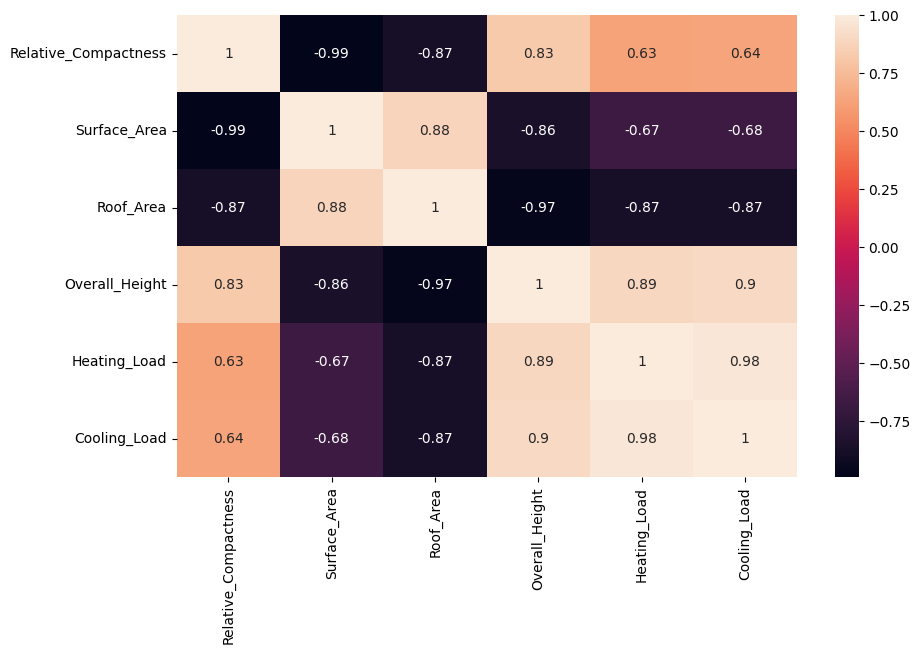

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
ax = sns.heatmap(np.round(R,3), annot=True)
plt.show()

* **Heating_Load** and **Cooling_Load** have the highest positive correlation coefficient of 0.98, indicating a strong positive linear relationship between them. This suggests that buildings with higher heating loads also tend to have higher cooling loads, and vice versa. Therefore, these two variables are dependent on each other.

* **Surface_Area and Roof_Area** have a high negative correlation coefficient of -0.87. This suggests that as the surface area of a building increases, the roof area tends to decrease, and vice versa. However, this relationship is not as strong as the correlation between heating and cooling loads.

### From the output of above two cells we can say that there are dependent variables

In [ ]:
cov_matrix=np.cov(df.T)
cov_matrix

array([[ 1.        , -0.99188872, -0.86785473,  0.82803772,  0.63184593,
         0.64149586],
       [-0.99188872,  1.        ,  0.87965112, -0.8581667 , -0.66624701,
        -0.67898084],
       [-0.86785473,  0.87965112,  1.        , -0.97261407, -0.87012715,
        -0.86819069],
       [ 0.82803772, -0.8581667 , -0.97261407,  1.        ,  0.89430261,
         0.898737  ],
       [ 0.63184593, -0.66624701, -0.87012715,  0.89430261,  1.        ,
         0.97594962],
       [ 0.64149586, -0.67898084, -0.86819069,  0.898737  ,  0.97594962,
         1.        ]])

We are taking transpose to ensure that the variables are represented as columns and observations as rows in the resulting matrix.

In [ ]:
from numpy import linalg as LA

lambdas, eig_vector = LA.eig(np.array(cov_matrix))
print(lambdas)
print(eig_vector)

[5.18268936e+00 6.80014317e-01 8.18638957e-02 4.12934493e-03
 3.01062314e-02 2.11968532e-02]
[[-0.39053123  0.54287653  0.27209783  0.65848523 -0.19693503  0.0796681 ]
 [ 0.39955194 -0.48854029 -0.28085913  0.67009924 -0.22492602  0.15225005]
 [ 0.43063642 -0.01582662  0.57257379  0.23738734  0.53223019 -0.38319618]
 [-0.43018438 -0.07354213 -0.54586757  0.24566965  0.58167409 -0.33595123]
 [-0.39736869 -0.48846895  0.28762373 -0.00689501 -0.4212105  -0.58592062]
 [-0.39929364 -0.4715428   0.37221144  0.02470527  0.33405519  0.6061909 ]]


### Using the above code, we can obtain the eigenvalue and eigenvector matrix from the variance covariance matrix

* In PCA, eigenvalues and eigenvectors are used to transform the data into a new coordinate system to reduce dimensionality while preserving the most important information in the data.

* In PCA, eigenvalues represent the amount of variance captured by each principal component. Typically, in PCA, you would use these eigenvalues to determine how many principal components to retain.

### Selecting Principal components

In [ ]:
# Make a list of (eigenvalue, eigenvector) tuples
eig_pairs = [(np.abs(lambdas[i]), eig_vector[:,i]) for i in range(len(lambdas))]

# Sort the (eigenvalue, eigenvector) tuples from high to low
eig_pairs.sort(key=lambda x: x[0], reverse=True)

# Confirm that the list is correctly sorted by decreasing eigenvalues
print('Eigenvalues in descending order:')
for i in eig_pairs:
    print(i[0])

Eigenvalues in descending order:
5.182689358050449
0.680014316774295
0.08186389566922346
0.030106231411133267
0.021196853165822663
0.004129344929079217


### Explained variance: It helps to choose the number of principal components we are going to use

In [ ]:
total = sum(lambdas)
var_exp = [(i / total)*100 for i in sorted(lambdas, reverse=True)]  #calculates the explained variance ratio for each principal component.
var_exp

[86.37815596750745,
 11.333571946238246,
 1.364398261153724,
 0.5017705235188876,
 0.3532808860970443,
 0.06882241548465359]

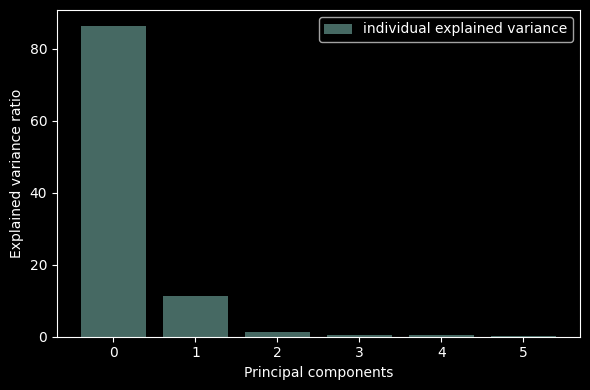

In [ ]:
with plt.style.context('dark_background'):
    plt.figure(figsize=(6, 4))

    plt.bar(range(6), var_exp, alpha=0.5, align='center',
            label='individual explained variance')
    plt.ylabel('Explained variance ratio')
    plt.xlabel('Principal components')
    plt.legend(loc='best')
    plt.tight_layout()

#### The plot above clearly shows that maximum variance (86.37%) can be explained by the first principal component alone.The second,third,fourth and fifth principal component share almost negligible variance therefore we are only going to consider the first component

## Projection Matrix

### Here, we are reducing the 6-dimensional feature space to a 1-dimensional feature subspace, by choosing the “top 1” eigenvectors with the highest eigenvalue to construct our eigenvector matrix

In [ ]:
matrix_w = np.hstack((eig_pairs[0][1]))
print('Matrix W:\n', matrix_w)

Matrix W:
 [-0.39053123  0.39955194  0.43063642 -0.43018438 -0.39736869 -0.39929364]


In [ ]:
Y = df.dot(matrix_w)
Y

0     -2.175807
4     -2.036225
5     -1.939338
6     -1.900698
7     -2.045865
         ...   
763    2.135723
764    2.563236
765    2.557547
766    2.576878
767    2.594842
Length: 756, dtype: float64

# BY USING SCIKITLEARN LIBRARY

<ipython-input-24-1b06c0acf3c5>:4: MatplotlibDeprecationWarning: Passing the emit parameter of set_xlim() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  plt.xlim(0,6,1)


Text(0, 0.5, 'Cumulative explained variance')

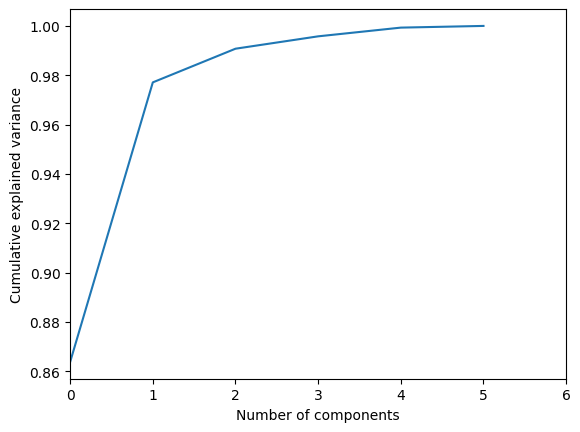

In [ ]:
from sklearn.decomposition import PCA
pca = PCA().fit(X)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlim(0,6,1)
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')

In [ ]:
sklearn_pca = PCA(n_components=1)
Y_sklearn = sklearn_pca.fit_transform(X)

In [ ]:
print(-Y_sklearn)

[[-2.17580711]
 [-2.03622456]
 [-1.93933786]
 [-1.90069834]
 [-2.04586485]
 [-1.4480213 ]
 [-1.24288158]
 [-1.28247386]
 [-1.42513224]
 [-0.94397037]
 [-0.86154002]
 [-0.83094097]
 [-0.95045548]
 [-1.75467497]
 [-1.53880817]
 [-1.51399594]
 [-1.83518587]
 [-1.2867383 ]
 [-1.24916386]
 [-1.23745925]
 [ 2.22007744]
 [ 2.20873996]
 [ 2.22076079]
 [ 2.20996857]
 [ 2.41596925]
 [ 2.39598056]
 [ 2.41513321]
 [ 2.39807067]
 [ 2.56344166]
 [ 2.55283844]
 [ 2.56700028]
 [ 2.55706955]
 [ 2.74603313]
 [ 2.75628009]
 [ 2.74917372]
 [ 2.76004228]
 [ 2.60482802]
 [ 2.61616176]
 [ 2.60922267]
 [ 2.6208109 ]
 [ 3.07600831]
 [ 3.07405629]
 [ 3.08147889]
 [ 3.08118811]
 [-2.74516442]
 [-2.74294707]
 [-2.74587322]
 [-2.7380326 ]
 [-2.55170459]
 [-2.45718419]
 [-2.41640367]
 [-2.5737437 ]
 [-1.86425614]
 [-1.66785483]
 [-1.70643294]
 [-1.85972   ]
 [-1.34633788]
 [-1.26564138]
 [-1.23386461]
 [-1.35920597]
 [-2.19616551]
 [-1.98987317]
 [-1.9457047 ]
 [-2.28005689]
 [-1.77880911]
 [-1.75419334]
 [-1.78931